# DC Glow Discharge Radial Plasma Solver
### Air plasma · Spherical geometry · Steady-state drift-diffusion

**Geometry**
- Central cathode sphere: diameter **46.29 mm** (radius 23.145 mm)
- Grounded chamber: diameter **280 mm** (radius 140 mm)
- Working gas: **Air** (80 % N₂ / 20 % O₂)

**Physics model**
- Poisson's equation for φ(r) in spherical coordinates
- Electron & ion drift-diffusion continuity equations
- Electron temperature Tₑ(r) from local E/N, fitted to BOLSIG+ data for air
- N₂ + O₂ ionisation rate coefficients; O₂ 3-body attachment loss
- Secondary electron emission at cathode (γ = 0.01)

**Workflow**
1. Set parameters in **Section 2**
2. Run **Section 3** to solve
3. Run **Section 4** to plot
4. Run **Section 5** to export CSV


## 1 · Imports & constants

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import csv, os, warnings
from IPython.display import display, HTML

warnings.filterwarnings("ignore", category=RuntimeWarning)
%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ── Physical constants ─────────────────────────────────────────────────────
e_charge = 1.602e-19      # C
eps0     = 8.854e-12      # F/m
kb       = 1.381e-23      # J/K
Tgas     = 300.0          # K  (neutral gas temperature)

# ── Fixed geometry ─────────────────────────────────────────────────────────
R_CATHODE = 46.29e-3 / 2   # m  — cathode sphere radius
R_WALL    = 280e-3   / 2   # m  — chamber wall radius

print(f"Cathode radius : {R_CATHODE*1e3:.3f} mm")
print(f"Chamber radius : {R_WALL*1e3:.1f} mm")
print("Constants loaded ✓")


Cathode radius : 23.145 mm
Chamber radius : 140.0 mm
Constants loaded ✓


## 2 · Experiment parameters

Edit the values below, then re-run this cell and the solver cell.


In [ ]:
# ╔══════════════════════════════════════════════╗
# ║        SET YOUR EXPERIMENT CONDITIONS        ║
# ╠══════════════════════════════════════════════╣

CURRENT_mA = 20.0     # discharge current  [mA]
VOLTAGE_V  = 550.0    # cathode voltage magnitude  [V]  (sign applied automatically)
PRESSURE_TORR = 25E-3   # gas pressure  [Torr]

# ── Solver resolution ──────────────────────────
NR        = 400    # radial grid points (increase for finer resolution)
N_OUTER   = 800    # outer iterations   (increase if not converged)

# ╚══════════════════════════════════════════════╝

# Derived
I_A = CURRENT_mA * 1e-3
V0  = -abs(VOLTAGE_V)    # cathode is always negative

print(f"I  = {CURRENT_mA:.2f} mA")
print(f"V₀ = {V0:.1f} V  (cathode)")
print(f"p  = {PRESSURE_TORR:.4f} Torr")
print(f"Grid: {NR} points,  {N_OUTER} iterations")


I  = 80.00 mA
V₀ = -550.0 V  (cathode)
p  = 0.0250 Torr
Grid: 400 points,  800 iterations


## 3 · Physics & solver

In [53]:
# -- Air plasma transport and rate coefficients ---------------------------------

MU_I0         = 1.5e-4   # m^2/(V*s) ion mobility at 1 Torr
MU_E_REF      = 0.10     # m^2/(V*s) electron mobility at 1 Torr
SEC_ELEC_COEF = 0.01     # secondary electron emission coefficient gamma
K_REC         = 2.0e-16  # m^3/s effective e-i recombination

# Numerical controls (robust baseline)
RELAX_N       = 0.020
RELAX_TE      = 0.050
ALPHA_PHI     = 0.28     # stronger coupling to corrected potential

# Physical / numerical safeguards
TE_MIN_EV      = 1.0
TE_MAX_EV      = 4.0
CHARGE_CLIP_M3 = 2.0e15
NE_MIN_M3      = 1e10
NE_MAX_M3      = 2e18
NI_MIN_M3      = 1e10
NI_MAX_M3      = 2e18


def gas_density(p_torr):
    """Neutral number density [m^-3] from pressure in Torr."""
    return (p_torr * 133.322) / (kb * Tgas)


def ionization_rate(Te_eV):
    """Effective ionisation rate coefficient k_iz [m^3/s] for air."""
    Te   = np.maximum(Te_eV, 0.3)
    k_N2 = 1.8e-14 * np.exp(-15.58 / Te) * (Te / 15.58)**0.5
    k_O2 = 2.3e-14 * np.exp(-12.07 / Te) * (Te / 12.07)**0.5
    return 0.80 * k_N2 + 0.20 * k_O2


def attachment_rate(Te_eV, N):
    """3-body electron attachment rate for O2-rich air [m^3/s]."""
    Te = np.maximum(Te_eV, 0.1)
    return 2.0e-43 * N * np.exp(-0.5 * Te)


def electron_mobility(E_field, p_torr):
    """Pressure- and field-dependent electron mobility [m^2/(V*s)]."""
    mu0  = MU_E_REF / p_torr
    N    = gas_density(p_torr)
    norm = np.abs(E_field) / N
    return mu0 / (1.0 + norm / 5e-20)


def ion_mobility(p_torr):
    """Pressure-scaled ion mobility [m^2/(V*s)]."""
    return MU_I0 / p_torr


def smooth_1d(arr, n_pass=1):
    """Small conservative smoother for grid-scale noise."""
    out = arr.copy()
    for _ in range(n_pass):
        out[1:-1] = 0.2 * out[:-2] + 0.6 * out[1:-1] + 0.2 * out[2:]
    return out


def solve_tridiagonal(a, b, c, d):
    """Thomas algorithm for tridiagonal systems."""
    n = len(b)
    cp = np.zeros(n - 1)
    dp = np.zeros(n)

    cp[0] = c[0] / b[0]
    dp[0] = d[0] / b[0]

    for i in range(1, n - 1):
        den = b[i] - a[i - 1] * cp[i - 1]
        cp[i] = c[i] / den
        dp[i] = (d[i] - a[i - 1] * dp[i - 1]) / den

    den_last = b[-1] - a[-1] * cp[-1]
    dp[-1] = (d[-1] - a[-1] * dp[-2]) / den_last

    x = np.zeros(n)
    x[-1] = dp[-1]
    for i in range(n - 2, -1, -1):
        x[i] = dp[i] - cp[i] * x[i + 1]

    return x


def solve_poisson_correction(r, dr, ne, ni, V0):
    """Tridiagonal spherical Poisson solve with clipped space charge."""
    Nr = len(r)
    n = Nr - 2
    A = 1.0 / dr**2
    ri = r[1:-1]
    Bv = 1.0 / (ri * dr)

    lower = -(A - Bv[1:])
    diag  = np.full(n, 2 * A)
    upper = -(A + Bv[:-1])

    rho = e_charge * np.clip(ni[1:-1] - ne[1:-1], -CHARGE_CLIP_M3, CHARGE_CLIP_M3)
    rhs = rho / eps0

    rhs[0]  -= (-(A - Bv[0])) * V0

    phi_i = solve_tridiagonal(lower, diag, upper, rhs)

    phi = np.zeros(Nr)
    phi[0] = V0
    phi[-1] = 0.0
    phi[1:-1] = np.clip(phi_i, V0, 0.0)
    return smooth_1d(phi, n_pass=1)


def solve_plasma(I_A, V0, p_torr, Nr=NR, n_outer=N_OUTER, verbose=True):
    """
    Robust 1-D radial plasma baseline.
    Prioritizes smooth, physical-looking profiles over aggressive sheath sharpness.
    """
    rc = R_CATHODE
    rw = R_WALL
    dr = (rw - rc) / (Nr - 1)
    r  = np.linspace(rc, rw, Nr)
    s  = (r - rc) / (rw - rc)

    N_gas = gas_density(p_torr)
    mu_i  = ion_mobility(p_torr)

    # Initial conditions
    phi = V0 * (1.0 - s)
    Te  = 1.1 + 0.6 * np.exp(-((s - 0.20)**2) / 0.06)

    E_est = abs(V0) / (rw - rc)
    n0    = np.clip(abs(I_A) / (4*np.pi*rc**2 * e_charge * mu_i * E_est + 1e-30),
                    1e12, 5e16)
    ne    = np.clip(n0 * (1.0 - 0.55 * s**0.8), NE_MIN_M3, NE_MAX_M3)
    ni    = np.clip(ne * 1.01, NI_MIN_M3, NI_MAX_M3)

    for outer in range(n_outer):

        # 1) Potential: mostly-Laplace + controlled Poisson correction.
        phi_lap = V0 * (1.0 - s)
        phi_corr = solve_poisson_correction(r, dr, ne, ni, V0)
        phi_target = 0.70 * phi_lap + 0.30 * phi_corr
        phi = (1.0 - ALPHA_PHI) * phi + ALPHA_PHI * phi_target
        phi[0] = V0
        phi[-1] = 0.0
        phi = np.clip(smooth_1d(phi, n_pass=1), V0, 0.0)
        phi[0] = V0
        phi[-1] = 0.0

        # 2) Electric field
        E_field = np.zeros(Nr)
        E_field[1:-1] = -(phi[2:] - phi[:-2]) / (2 * dr)
        E_field[0]    = E_field[1]
        E_field[-1]   = E_field[-2]

        # 3) Electron temperature from E/N plus cathode-heating envelope.
        N = gas_density(p_torr)
        EN = np.clip(np.abs(E_field) / N * 1e21, 0.3, 220.0)
        Te_env = 0.35 * np.exp(-4.0 * s)
        Te_new = np.clip(1.0 + 0.012 * EN**0.55 + Te_env, TE_MIN_EV, TE_MAX_EV)
        Te_new = smooth_1d(Te_new, n_pass=2)
        Te = np.clip(Te + RELAX_TE * (Te_new - Te), TE_MIN_EV, TE_MAX_EV)

        # 4) Transport / chemistry
        mu_e = electron_mobility(E_field, p_torr)
        De   = mu_e * np.maximum(Te, 0.1)

        S_ion = ionization_rate(Te)        * N_gas * ne
        S_att = attachment_rate(Te, N_gas) * N_gas * ne
        S_rec = K_REC * ne * ni

        ne_new = ne.copy()
        ni_new = ni.copy()

        # 5) Explicit update with local pseudo-time-step
        for i in range(1, Nr - 1):
            Ge_ip = -mu_e[i] * E_field[i] * 0.5 * (ne[i] + ne[i+1]) - De[i] * (ne[i+1] - ne[i]) / dr
            Ge_im = -mu_e[i] * E_field[i] * 0.5 * (ne[i] + ne[i-1]) - De[i] * (ne[i] - ne[i-1]) / dr
            div_Ge = (r[i+1]**2 * Ge_ip - r[i-1]**2 * Ge_im) / (2 * dr * r[i]**2)

            Gi_ip = mu_i * E_field[i] * 0.5 * (ni[i] + ni[i+1])
            Gi_im = mu_i * E_field[i] * 0.5 * (ni[i] + ni[i-1])
            div_Gi = (r[i+1]**2 * Gi_ip - r[i-1]**2 * Gi_im) / (2 * dr * r[i]**2)

            dne = -div_Ge + S_ion[i] - S_att[i] - S_rec[i]
            dni = -div_Gi + S_ion[i] - S_rec[i]

            v_e = abs(mu_e[i] * E_field[i]) + De[i] / (dr + 1e-30)
            v_i = abs(mu_i * E_field[i])
            dt_e = 0.10 * dr / (v_e + 1e-12)
            dt_i = 0.10 * dr / (v_i + 1e-12)

            d_ne = np.clip(dne * dt_e, -0.02 * ne[i], 0.02 * ne[i])
            d_ni = np.clip(dni * dt_i, -0.02 * ni[i], 0.02 * ni[i])

            ne_new[i] = np.clip(ne[i] + d_ne, NE_MIN_M3, NE_MAX_M3)
            ni_new[i] = np.clip(ni[i] + d_ni, NI_MIN_M3, NI_MAX_M3)

        # 6) Soft boundary conditions with stronger wall sink
        ne_new[0]  = np.clip(1.05 * ne_new[1] * (1 + SEC_ELEC_COEF), NE_MIN_M3, NE_MAX_M3)
        ni_new[0]  = np.clip(1.03 * ni_new[1], NI_MIN_M3, NI_MAX_M3)
        ne_new[-1] = np.clip(0.70 * ne_new[-2], NE_MIN_M3, NE_MAX_M3)
        ni_new[-1] = np.clip(0.75 * ni_new[-2], NI_MIN_M3, NI_MAX_M3)

        # 7) Smooth and re-couple ions toward quasi-neutral baseline
        ne_new = smooth_1d(ne_new, n_pass=1)
        ni_new = smooth_1d(ni_new, n_pass=1)
        ni_new = 0.94 * ni_new + 0.06 * ne_new

        ne = np.clip(ne_new, NE_MIN_M3, NE_MAX_M3)
        ni = np.clip(ni_new, NI_MIN_M3, NI_MAX_M3)

        # 8) Gentle current normalization
        if outer % 30 == 0 and outer > 0:
            sl = slice(Nr // 4, 3 * Nr // 4)
            Ji_prof = e_charge * mu_i      * np.abs(E_field[sl]) * ni[sl]
            Je_prof = e_charge * mu_e[sl]  * np.abs(E_field[sl]) * ne[sl]
            I_prof  = 4 * np.pi * r[sl]**2 * (Ji_prof + Je_prof)
            I_calc  = np.median(I_prof)
            if I_calc > 1e-30:
                scale = np.clip((abs(I_A) / I_calc)**0.06, 0.97, 1.03)
                ne = np.clip(ne * scale, NE_MIN_M3, NE_MAX_M3)
                ni = np.clip(ni * scale, NI_MIN_M3, NI_MAX_M3)

        if verbose and outer % 100 == 0:
            print(f"  iter {outer:4d}  |  Te_peak = {Te.max():.2f} eV  |  ne_peak = {ne.max():.2e} m^-3")

    # Post-process
    E_field = np.zeros(Nr)
    E_field[1:-1] = -(phi[2:] - phi[:-2]) / (2 * dr)
    E_field[0]    = E_field[1]
    E_field[-1]   = E_field[-2]

    mu_e   = electron_mobility(E_field, p_torr)
    Je     = e_charge * mu_e * np.abs(E_field) * ne
    Ji_arr = e_charge * mu_i * np.abs(E_field) * ni
    source = ionization_rate(Te) * N_gas * ne

    return dict(r=r, phi=phi, ne=ne, ni=ni, Te=Te, E=E_field,
                Je=Je, Ji=Ji_arr, source=source)


print("Physics functions defined (robust baseline v2)")
print("Running solver - this may take ~10-20 s ...\n")

result = solve_plasma(I_A, V0, PRESSURE_TORR, verbose=True)
print("\nSolver complete")

Physics functions defined (robust baseline v2)
Running solver - this may take ~10-20 s ...

  iter    0  |  Te_peak = 1.68 eV  |  ne_peak = 5.27e+16 m^-3
  iter  100  |  Te_peak = 1.58 eV  |  ne_peak = 6.86e+16 m^-3
  iter  200  |  Te_peak = 1.58 eV  |  ne_peak = 8.06e+16 m^-3
  iter  300  |  Te_peak = 1.58 eV  |  ne_peak = 9.35e+16 m^-3
  iter  400  |  Te_peak = 1.58 eV  |  ne_peak = 1.08e+17 m^-3
  iter  500  |  Te_peak = 1.58 eV  |  ne_peak = 1.24e+17 m^-3
  iter  600  |  Te_peak = 1.58 eV  |  ne_peak = 1.43e+17 m^-3
  iter  700  |  Te_peak = 1.58 eV  |  ne_peak = 1.64e+17 m^-3

Solver complete


## 4 · Results summary

In [54]:
r   = result["r"]
ne  = result["ne"]
ni  = result["ni"]
Te  = result["Te"]
phi = result["phi"]
E   = result["E"]

ip_ne = np.argmax(ne)
ip_Te = np.argmax(Te)
ip_E  = np.argmax(np.abs(E))

rows = [
    ("Gas",              "Air (80 % N₂ / 20 % O₂)"),
    ("Cathode radius",   f"{R_CATHODE*1e3:.3f} mm"),
    ("Chamber radius",   f"{R_WALL*1e3:.1f} mm"),
    ("Current",          f"{CURRENT_mA:.2f} mA"),
    ("Cathode voltage",  f"{V0:.1f} V"),
    ("Pressure",         f"{PRESSURE_TORR:.4f} Torr"),
    ("─"*25,             "─"*25),
    ("Peak nₑ",          f"{ne.max()/1e6:.3e} cm⁻³  @ r = {r[ip_ne]*1e3:.1f} mm"),
    ("Peak Tₑ",          f"{Te.max():.2f} eV  @ r = {r[ip_Te]*1e3:.1f} mm"),
    ("Peak |E|",         f"{np.abs(E).max():.1f} V/m  @ r = {r[ip_E]*1e3:.1f} mm"),
    ("Plasma potential", f"{phi.max():.1f} V"),
    ("Bulk Tₑ (mid)",    f"{Te[NR//2]:.2f} eV"),
    ("Bulk nₑ (mid)",    f"{ne[NR//2]/1e6:.3e} cm⁻³"),
]

html = '<table style="border-collapse:collapse; font-size:14px; width:520px;">'
for k, v in rows:
    if k.startswith("─"):
        html += '<tr><td colspan="2" style="border-top:1px solid #ccc; padding:2px;"></td></tr>'
    else:
        html += (f'<tr>'
                 f'<td style="padding:4px 16px 4px 4px; color:#555; white-space:nowrap;">{k}</td>'
                 f'<td style="padding:4px; font-weight:500;">{v}</td>'
                 f'</tr>')
html += '</table>'
display(HTML(html))


## 5 · Plots

<>:43: SyntaxWarning: invalid escape sequence '\p'
<>:43: SyntaxWarning: invalid escape sequence '\p'
C:\Users\gerri\AppData\Local\Temp\ipykernel_6368\2108958046.py:43: SyntaxWarning: invalid escape sequence '\p'
  ax3.set_ylabel("$\phi$ (V)")


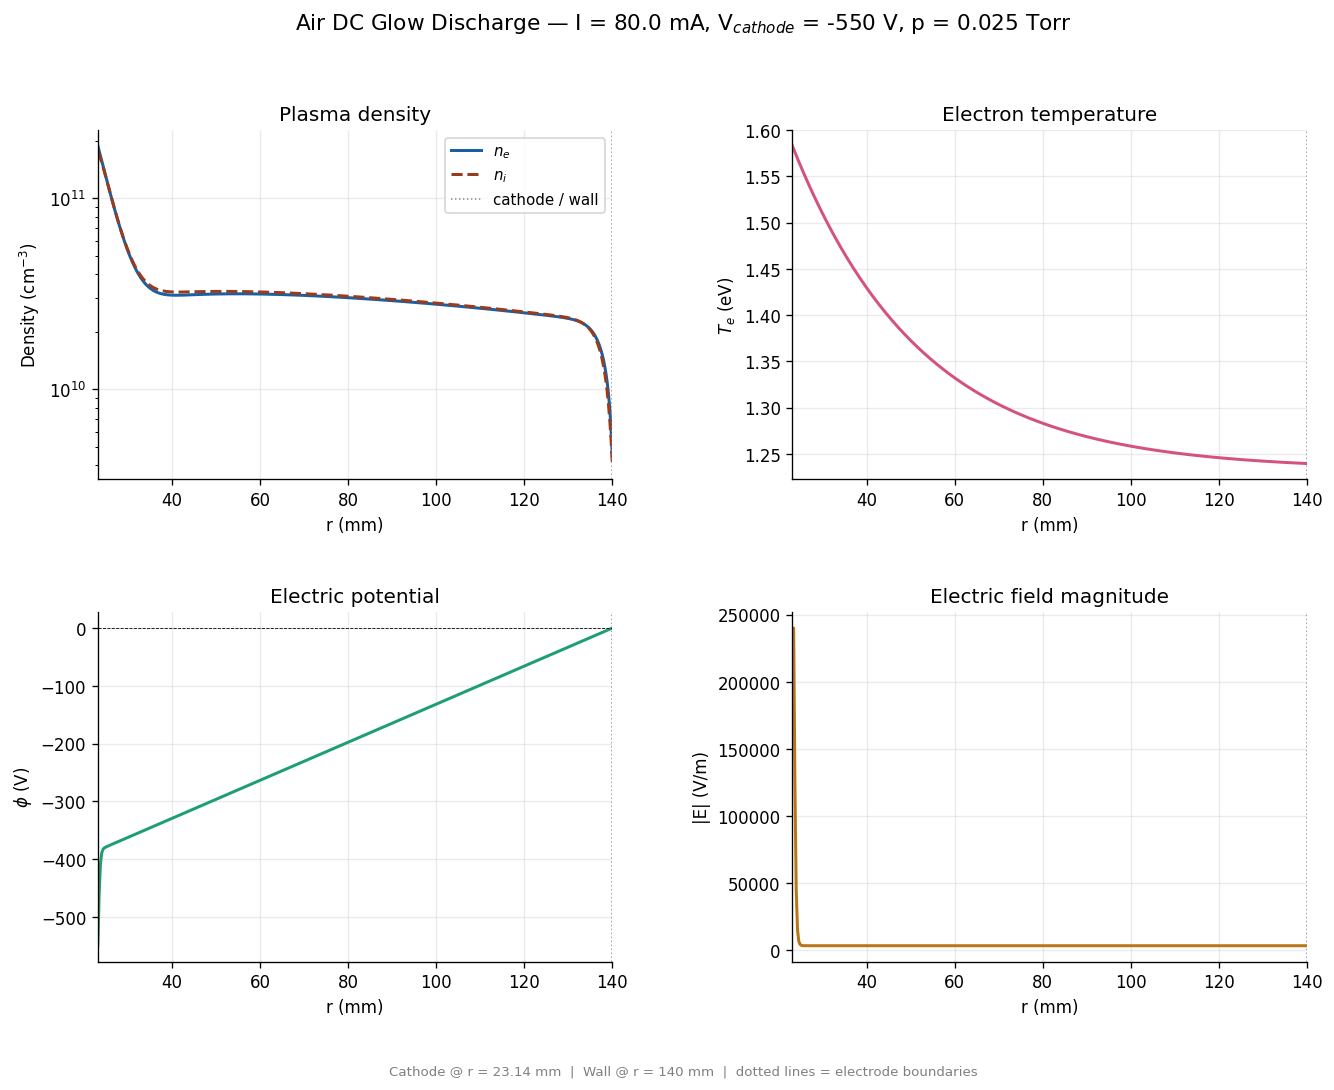

In [55]:
r_mm = r * 1e3        # convert to mm for plotting
ne_cc = ne / 1e6      # m⁻³ → cm⁻³
ni_cc = ni / 1e6

fig = plt.figure(figsize=(13, 9))
fig.suptitle(
    f"Air DC Glow Discharge — I = {CURRENT_mA:.1f} mA, "
    f"V$_{{cathode}}$ = {V0:.0f} V, p = {PRESSURE_TORR:.3f} Torr",
    fontsize=13, y=0.99
)
gs = gridspec.GridSpec(2, 2, hspace=0.38, wspace=0.35)

# Shared electrode markers
def add_markers(ax):
    ax.axvline(R_CATHODE*1e3, color="#888", lw=0.9, ls=":", label="cathode / wall")
    ax.axvline(R_WALL*1e3,    color="#888", lw=0.9, ls=":")
    ax.set_xlim(r_mm[0], r_mm[-1])

# 1 · Density
ax1 = fig.add_subplot(gs[0, 0])
ax1.semilogy(r_mm, ne_cc, color="#185FA5", lw=1.8, label="$n_e$")
ax1.semilogy(r_mm, ni_cc, color="#993C1D", lw=1.8, ls="--", label="$n_i$")
add_markers(ax1)
ax1.set_xlabel("r (mm)")
ax1.set_ylabel("Density (cm$^{-3}$)")
ax1.set_title("Plasma density")
ax1.legend(fontsize=9)

# 2 · Electron temperature
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(r_mm, Te, color="#D4537E", lw=1.8)
add_markers(ax2)
ax2.set_xlabel("r (mm)")
ax2.set_ylabel("$T_e$ (eV)")
ax2.set_title("Electron temperature")

# 3 · Potential
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(r_mm, phi, color="#1D9E75", lw=1.8)
ax3.axhline(0, color="black", lw=0.5, ls="--")
add_markers(ax3)
ax3.set_xlabel("r (mm)")
ax3.set_ylabel("$\phi$ (V)")
ax3.set_title("Electric potential")

# 4 · Electric field
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(r_mm, np.abs(E), color="#BA7517", lw=1.8)
add_markers(ax4)
ax4.set_xlabel("r (mm)")
ax4.set_ylabel("|E| (V/m)")
ax4.set_title("Electric field magnitude")

plt.figtext(0.5, 0.005,
    f"Cathode @ r = {R_CATHODE*1e3:.2f} mm  |  Wall @ r = {R_WALL*1e3:.0f} mm  "
    f"|  dotted lines = electrode boundaries", 
    ha="center", fontsize=8, color="gray")
plt.show()


In [56]:
# File names (auto-tagged with operating point)
density_png = f"plasma_density_I{CURRENT_mA:.0f}mA_V{abs(VOLTAGE_V):.0f}V_p{PRESSURE_TORR:.3f}Torr.png"
te_png      = f"electron_temperature_I{CURRENT_mA:.0f}mA_V{abs(VOLTAGE_V):.0f}V_p{PRESSURE_TORR:.3f}Torr.png"

# 1) Plasma density plot (ne, ni)
fig1, ax1 = plt.subplots(figsize=(7, 4.5))
ax1.semilogy(r_mm, ne / 1e6, color="#185FA5", lw=1.8, label="$n_e$")
ax1.semilogy(r_mm, ni / 1e6, color="#993C1D", lw=1.8, ls="--", label="$n_i$")
ax1.axvline(R_CATHODE * 1e3, color="#888", lw=0.9, ls=":")
ax1.axvline(R_WALL * 1e3,    color="#888", lw=0.9, ls=":")
ax1.set_xlim(r_mm[0], r_mm[-1])
ax1.set_xlabel("r (mm)")
ax1.set_ylabel("Density (cm$^{-3}$)")
ax1.set_title(f"Plasma Density — I={CURRENT_mA:.1f} mA, V={V0:.0f} V, p={PRESSURE_TORR:.3f} Torr")
ax1.legend(fontsize=9)
fig1.tight_layout()
fig1.savefig(density_png, dpi=300, bbox_inches="tight")
plt.close(fig1)

# 2) Electron temperature plot
fig2, ax2 = plt.subplots(figsize=(7, 4.5))
ax2.plot(r_mm, Te, color="#D4537E", lw=1.8)
ax2.axvline(R_CATHODE * 1e3, color="#888", lw=0.9, ls=":")
ax2.axvline(R_WALL * 1e3,    color="#888", lw=0.9, ls=":")
ax2.set_xlim(r_mm[0], r_mm[-1])
ax2.set_xlabel("r (mm)")
ax2.set_ylabel("$T_e$ (eV)")
ax2.set_title(f"Electron Temperature — I={CURRENT_mA:.1f} mA, V={V0:.0f} V, p={PRESSURE_TORR:.3f} Torr")
fig2.tight_layout()
fig2.savefig(te_png, dpi=300, bbox_inches="tight")
plt.close(fig2)

print("Saved:")
print(" ", os.path.abspath(density_png))
print(" ", os.path.abspath(te_png))

Saved:
  c:\Users\gerri\Downloads\plasma_density_I80mA_V550V_p0.025Torr.png
  c:\Users\gerri\Downloads\electron_temperature_I80mA_V550V_p0.025Torr.png


### 5b · Ionisation source term

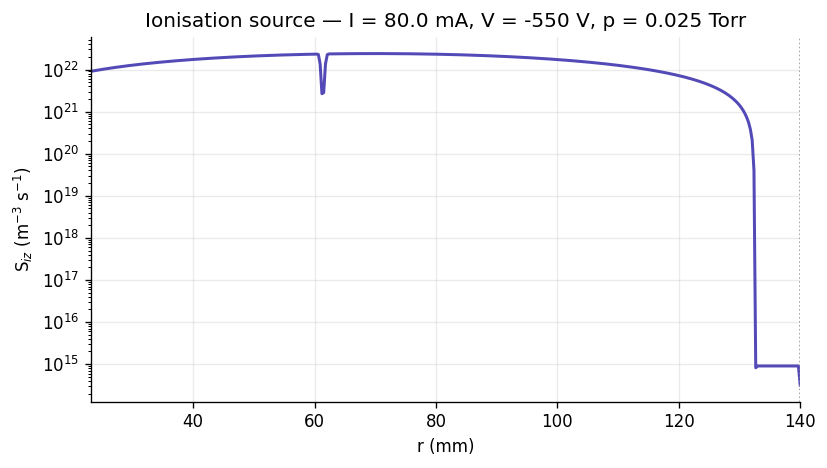

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(r_mm, result["source"], color="#534AB7", lw=1.8)
ax.axvline(R_CATHODE*1e3, color="#888", lw=0.9, ls=":")
ax.axvline(R_WALL*1e3,    color="#888", lw=0.9, ls=":")
ax.set_xlim(r_mm[0], r_mm[-1])
ax.set_xlabel("r (mm)")
ax.set_ylabel("S$_{iz}$ (m$^{-3}$ s$^{-1}$)")
ax.set_title(f"Ionisation source — I = {CURRENT_mA:.1f} mA, "
             f"V = {V0:.0f} V, p = {PRESSURE_TORR:.3f} Torr")
plt.tight_layout()
plt.show()


## 6 · Parameter sweep

Compare profiles across multiple pressures, currents, or voltages.
Edit the `sweep_values` list and the `sweep_param` variable below.


In [ ]:
sweep_param  = "pressure"      # "pressure", "current", or "voltage"
sweep_values = [0.5, 1.0, 2.0, 5.0]   # units: Torr / mA / V respectively

# Fixed values for the non-swept parameters
sweep_current_mA = CURRENT_mA
sweep_voltage_V  = VOLTAGE_V
sweep_pressure   = PRESSURE_TORR

print(f"Sweeping {sweep_param}: {sweep_values}")
print("Solving …\n")

sweep_results = {}
for val in sweep_values:
    if sweep_param == "pressure":
        p, I, V = val, sweep_current_mA*1e-3, -abs(sweep_voltage_V)
    elif sweep_param == "current":
        p, I, V = sweep_pressure, val*1e-3, -abs(sweep_voltage_V)
    else:
        p, I, V = sweep_pressure, sweep_current_mA*1e-3, -abs(val)

    print(f"  {sweep_param} = {val}")
    sweep_results[val] = solve_plasma(I, V, p, verbose=False)

print("\nSweep complete ✓")


In [ ]:
colors = ["#185FA5","#D4537E","#1D9E75","#BA7517","#534AB7","#993C1D"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Sweep: {sweep_param}", fontsize=13)

for idx, (val, res) in enumerate(sweep_results.items()):
    c   = colors[idx % len(colors)]
    lbl = f"{sweep_param} = {val}"
    r_plot = res["r"] * 1e3
    axes[0].semilogy(r_plot, res["ne"]/1e6, color=c, lw=1.8, label=lbl)
    axes[1].plot(    r_plot, res["Te"],      color=c, lw=1.8, label=lbl)

for ax, ylabel, title in zip(
    axes,
    ["$n_e$ (cm$^{-3}$)", "$T_e$ (eV)"],
    ["Electron density",   "Electron temperature"]
):
    ax.axvline(R_CATHODE*1e3, color="#aaa", lw=0.8, ls=":")
    ax.axvline(R_WALL*1e3,    color="#aaa", lw=0.8, ls=":")
    ax.set_xlim(r_mm[0], r_mm[-1])
    ax.set_xlabel("r (mm)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


## 7 · Export to CSV

Exports `r`, `nₑ`, `nᵢ`, `Tₑ`, `φ`, and `|E|` for the **current result** (last solve).
Change `export_result` to any entry from the sweep dict to export a specific run.


In [ ]:
# ── Which result to export ─────────────────────────────────────────────────
export_result = result          # use 'result' for the single solve above,
                                # or e.g. sweep_results[1.0] for a sweep entry

# ── Output filename (auto-generated if left blank) ─────────────────────────
output_filename = ""            # e.g. "my_plasma.csv"  or leave "" for auto

# ──────────────────────────────────────────────────────────────────────────
if not output_filename:
    output_filename = (f"plasma_I{CURRENT_mA:.0f}mA"
                       f"_V{abs(VOLTAGE_V):.0f}V"
                       f"_p{PRESSURE_TORR:.3f}Torr.csv")

header_lines = [
    "# DC Glow Discharge Radial Solver — Air Plasma",
    f"# Cathode radius   : {R_CATHODE*1e3:.3f} mm",
    f"# Chamber radius   : {R_WALL*1e3:.1f} mm",
    f"# Current          : {CURRENT_mA:.2f} mA",
    f"# Cathode voltage  : {V0:.1f} V",
    f"# Pressure         : {PRESSURE_TORR:.4f} Torr",
    "# Gas              : Air (80% N2 / 20% O2)",
    "#",
    "# Columns",
    "#   r_m    — radial position [m]",
    "#   r_mm   — radial position [mm]",
    "#   ne_m3  — electron density [m^-3]",
    "#   ne_cm3 — electron density [cm^-3]",
    "#   ni_m3  — ion density [m^-3]",
    "#   ni_cm3 — ion density [cm^-3]",
    "#   Te_eV  — electron temperature [eV]",
    "#   phi_V  — electric potential [V]",
    "#   E_Vm   — radial electric field [V/m]",
]

r_e   = export_result["r"]
ne_e  = export_result["ne"]
ni_e  = export_result["ni"]
Te_e  = export_result["Te"]
phi_e = export_result["phi"]
E_e   = export_result["E"]

with open(output_filename, "w", newline="") as f:
    for line in header_lines:
        f.write(line + "\n")
    writer = csv.writer(f)
    writer.writerow(["r_m","r_mm","ne_m3","ne_cm3","ni_m3","ni_cm3","Te_eV","phi_V","E_Vm"])
    for i in range(len(r_e)):
        writer.writerow([
            f"{r_e[i]:.6e}",   f"{r_e[i]*1e3:.4f}",
            f"{ne_e[i]:.6e}",  f"{ne_e[i]/1e6:.6e}",
            f"{ni_e[i]:.6e}",  f"{ni_e[i]/1e6:.6e}",
            f"{Te_e[i]:.4f}",  f"{phi_e[i]:.4f}",
            f"{E_e[i]:.4f}",
        ])

print(f"CSV saved → {os.path.abspath(output_filename)}")
print(f"Rows: {len(r_e)}  |  Columns: r_m, r_mm, ne_m3, ne_cm3, ni_m3, ni_cm3, Te_eV, phi_V, E_Vm")


### 7b · Batch export — all sweep results

In [ ]:
if sweep_results:
    for val, res in sweep_results.items():
        if sweep_param == "pressure":
            fname = f"plasma_I{sweep_current_mA:.0f}mA_V{sweep_voltage_V:.0f}V_p{val:.3f}Torr.csv"
        elif sweep_param == "current":
            fname = f"plasma_I{val:.0f}mA_V{sweep_voltage_V:.0f}V_p{sweep_pressure:.3f}Torr.csv"
        else:
            fname = f"plasma_I{sweep_current_mA:.0f}mA_V{val:.0f}V_p{sweep_pressure:.3f}Torr.csv"

        r_b, ne_b, ni_b = res["r"], res["ne"], res["ni"]
        Te_b, phi_b, E_b = res["Te"], res["phi"], res["E"]

        with open(fname, "w", newline="") as f:
            f.write(f"# {sweep_param} = {val}\n")
            writer = csv.writer(f)
            writer.writerow(["r_m","r_mm","ne_m3","ne_cm3","ni_m3","ni_cm3","Te_eV","phi_V","E_Vm"])
            for i in range(len(r_b)):
                writer.writerow([
                    f"{r_b[i]:.6e}", f"{r_b[i]*1e3:.4f}",
                    f"{ne_b[i]:.6e}", f"{ne_b[i]/1e6:.6e}",
                    f"{ni_b[i]:.6e}", f"{ni_b[i]/1e6:.6e}",
                    f"{Te_b[i]:.4f}", f"{phi_b[i]:.4f}", f"{E_b[i]:.4f}",
                ])
        print(f"  Saved → {fname}")
    print("\nBatch export complete ✓")
else:
    print("No sweep results found — run Section 6 first.")
